# NB11: LITTLE THINGS Ingestion — Dwarf Regime Stress Test

**Purpose:** Ingest Oh et al. (2015) rotation curves for 26 LITTLE THINGS dwarf galaxies,
derive baryonic velocity profiles from the total and DM-only rotation curves, apply
inclination QC, and insert into the database for RT fitting in NB12.

**Data source:** Oh et al. (2015), AJ, 149, 180. VizieR catalog J/AJ/149/180.
Downloaded via `scripts/fetch_little_things.py`.

**V_bary derivation:** LITTLE THINGS does not provide separate V_gas/V_disk/V_bulge
components. Instead, Oh et al. provide total rotation curves (`rotdmbar`) and DM-only
curves with baryonic contribution subtracted (`rotdm`). We derive:
```
V_bary = sqrt(max(0, V_total^2 - V_dm^2))
```
This is a documented departure from SPARC/THINGS where component separation is available.

**Key flags:**
- DDO 154 is a triple-overlap galaxy (SPARC + THINGS + LITTLE THINGS)
- Inclination QC: i > 30 deg (same threshold as THINGS)
- Beam-smearing: Oh et al. (2015) applied a first-order correction; curves are corrected

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.ingest import (
    load_little_things_galaxies,
    load_little_things_rotcurves,
    derive_little_things_vbary,
)
from src.database import (
    get_engine, get_session, init_db,
    Galaxy, RadialProfile, query_profiles_as_dataframe,
)

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

engine = init_db()
session = get_session(engine)

## 1. Load Galaxy Metadata

In [2]:
gal_df = load_little_things_galaxies()

print(f"LITTLE THINGS galaxies: {len(gal_df)}")
print(f"Missing MstarK:   {gal_df['MstarK'].isna().sum()}")
print(f"Missing MstarSED: {gal_df['MstarSED'].isna().sum()}")
print()

cols = ["Name", "Dist", "i", "Mgas", "MstarK", "MstarSED", "Rmax"]
print(gal_df[cols].to_string(index=False))

2026-04-09 23:22:24 | INFO     | src.ingest | Loaded 26 LITTLE THINGS galaxies


LITTLE THINGS galaxies: 26
Missing MstarK:   5
Missing MstarSED: 6

    Name  Dist    i   Mgas  MstarK  MstarSED  Rmax
 CVnIdwA   3.6 66.5   2.91    0.41      0.49  2.59
  DDO_43   7.8 40.6  23.26     NaN       NaN  4.19
  DDO_46   6.1 27.9  22.08     NaN       NaN  2.92
  DDO_47   5.2 45.5  46.80     NaN       NaN  7.71
  DDO_50   3.4 49.7 132.52    9.79     10.60  9.81
  DDO_52  10.3 43.0  33.43    7.20      5.31  5.43
  DDO_53   3.6 27.0   7.00    0.96      0.97  1.45
  DDO_70   1.3 50.0   3.80    1.24      1.96  2.00
  DDO_87   7.7 55.5  29.12    6.18      3.27  7.39
 DDO_101   6.4 51.0   3.48    5.79      6.54  1.95
 DDO_126   4.9 65.0  16.36    2.27      1.62  3.99
 DDO_133   3.5 43.4  12.85    2.62      3.04  3.48
 DDO_154   3.7 68.2  35.27    1.31      0.83  7.32
 DDO_168   4.3 46.5  25.94    5.13      5.85  3.14
 DDO_210   0.9 66.7   0.14    0.04      0.06  0.31
 DDO_216   1.1 63.7   0.49    1.60      1.51  1.12
 F564-V3   8.7 56.5   4.37     NaN       NaN  3.71
   IC_10   0.7

## 2. Inclination QC

Exclude galaxies with inclination < 30 deg (same threshold as THINGS Block 2).

In [3]:
INCL_THRESHOLD = 30.0

gal_df["qc_pass"] = gal_df["i"] >= INCL_THRESHOLD

print(f"{'Name':12s} {'i [deg]':>8s}  {'QC':>6s}")
print("-" * 30)
for _, r in gal_df.iterrows():
    status = "PASS" if r["qc_pass"] else "FAIL"
    print(f"{r['Name']:12s} {r['i']:8.1f}  {status:>6s}")

n_pass = gal_df["qc_pass"].sum()
n_fail = len(gal_df) - n_pass
print(f"\nQC pass: {n_pass}, fail: {n_fail}")

failed = gal_df[~gal_df["qc_pass"]]
if len(failed) > 0:
    print(f"\nExcluded (i < {INCL_THRESHOLD} deg):")
    for _, r in failed.iterrows():
        print(f"  {r['Name']} (i = {r['i']:.1f} deg)")

Name          i [deg]      QC
------------------------------
CVnIdwA          66.5    PASS
DDO_43           40.6    PASS
DDO_46           27.9    FAIL
DDO_47           45.5    PASS
DDO_50           49.7    PASS
DDO_52           43.0    PASS
DDO_53           27.0    FAIL
DDO_70           50.0    PASS
DDO_87           55.5    PASS
DDO_101          51.0    PASS
DDO_126          65.0    PASS
DDO_133          43.4    PASS
DDO_154          68.2    PASS
DDO_168          46.5    PASS
DDO_210          66.7    PASS
DDO_216          63.7    PASS
F564-V3          56.5    PASS
IC_10            47.0    PASS
IC_1613          48.0    PASS
NGC_1569         69.1    PASS
NGC_2366         63.0    PASS
NGC_3738         22.6    FAIL
UGC_8508         82.5    PASS
WLM              74.0    PASS
HARO_29          61.2    PASS
HARO_36          70.0    PASS

QC pass: 23, fail: 3

Excluded (i < 30.0 deg):
  DDO_46 (i = 27.9 deg)
  DDO_53 (i = 27.0 deg)
  NGC_3738 (i = 22.6 deg)


## 3. Load and De-normalize Rotation Curves

In [4]:
dmbar_data, dm_data = load_little_things_rotcurves()

print(f"Galaxies with total rotation curves (rotdmbar): {len(dmbar_data)}")
print(f"Galaxies with DM-only rotation curves (rotdm):  {len(dm_data)}")
print()

# Flag galaxies missing DM curves (cannot derive V_bary)
missing_dm = set(dmbar_data.keys()) - set(dm_data.keys())
if missing_dm:
    print(f"Missing DM curves (cannot derive V_bary): {sorted(missing_dm)}")
    print("These galaxies will be excluded from RT fitting but can contribute to BTFR via total M_bar.")
else:
    print("All galaxies have both rotation curve types.")

print()
print(f"{'Name':12s} {'N_dmbar':>8s} {'N_dm':>8s} {'R_max [kpc]':>12s}")
print("-" * 45)
qc_names = gal_df.loc[gal_df["qc_pass"], "Name"].values
for name in sorted(qc_names):
    n_dmbar = len(dmbar_data.get(name, []))
    n_dm = len(dm_data.get(name, []))
    r_max = dmbar_data[name]["radius_kpc"].max() if name in dmbar_data else np.nan
    dm_flag = "" if name in dm_data else " *NO DM*"
    print(f"{name:12s} {n_dmbar:8d} {n_dm:8d} {r_max:12.2f}{dm_flag}")

2026-04-09 23:22:24 | INFO     | src.ingest | Loaded LITTLE THINGS rotation curves: 26 dmbar, 22 dm


Galaxies with total rotation curves (rotdmbar): 26
Galaxies with DM-only rotation curves (rotdm):  22

Missing DM curves (cannot derive V_bary): ['DDO_46', 'DDO_47', 'F564-V3', 'HARO_29']
These galaxies will be excluded from RT fitting but can contribute to BTFR via total M_bar.

Name          N_dmbar     N_dm  R_max [kpc]
---------------------------------------------
CVnIdwA            14       12         2.59
DDO_101             9        9         2.32
DDO_126            30       30         3.99
DDO_133            19       19         3.48
DDO_154            55       55         7.89
DDO_168            33       30         3.99
DDO_210             8        8         0.31
DDO_216            13       13         1.12
DDO_43              9        9         4.19
DDO_47             34        0         7.71 *NO DM*
DDO_50             85       80         9.81
DDO_52             16       16         5.43
DDO_70             24       24         2.00
DDO_87             33       33         7.39
F564-

## 4. Derive V_bary Profiles

V_bary = sqrt(max(0, V_total^2 - V_dm^2)) at each radius.
DM-only curve is interpolated onto the total curve's radial grid.

In [5]:
# Derive V_bary for all QC-passing galaxies that have both curve types
profiles = {}  # name -> DataFrame(radius_kpc, v_obs, v_err, v_baryon_total)
excluded_no_dm = []

print(f"{'Name':12s} {'N_pts':>6s} {'V_bary range':>20s} {'Clamped':>8s}")
print("-" * 50)

for name in sorted(qc_names):
    if name not in dm_data:
        excluded_no_dm.append(name)
        continue

    prof, n_clamped = derive_little_things_vbary(dmbar_data[name], dm_data[name])
    profiles[name] = prof

    vb_min = prof["v_baryon_total"].min()
    vb_max = prof["v_baryon_total"].max()
    clamp_pct = n_clamped / len(prof) * 100
    flag = f" >{20}% WARN" if clamp_pct > 20 else ""
    print(f"{name:12s} {len(prof):6d} {vb_min:8.1f} - {vb_max:8.1f} km/s"
          f" {n_clamped:4d} ({clamp_pct:.0f}%){flag}")

print(f"\nProfiles derived: {len(profiles)}")
if excluded_no_dm:
    print(f"Excluded (no DM curve): {excluded_no_dm}")

Name          N_pts         V_bary range  Clamped
--------------------------------------------------
CVnIdwA          14      3.9 -      8.9 km/s    0 (0%)
DDO_101           9      0.0 -     13.2 km/s    1 (11%)
DDO_126          30      1.6 -     18.7 km/s    0 (0%)
DDO_133          19      1.9 -     18.8 km/s    0 (0%)
DDO_154          55      1.7 -     19.9 km/s    0 (0%)
DDO_168          33      2.9 -     22.6 km/s    0 (0%)
DDO_210           8      0.0 -      5.6 km/s    1 (12%)
DDO_216          13      0.0 -      8.4 km/s    1 (8%)
DDO_43            9      3.2 -     18.4 km/s    0 (0%)
DDO_50           85      0.0 -     33.9 km/s    7 (8%)
DDO_52           16      4.7 -     22.5 km/s    0 (0%)
DDO_70           24      0.0 -     28.1 km/s    9 (38%) >20% WARN
DDO_87           33      1.0 -     18.8 km/s    0 (0%)
HARO_36          10      6.4 -     19.9 km/s    0 (0%)
IC_10            25      0.0 -     32.7 km/s    4 (16%)
IC_1613         109      0.0 -     15.3 km/s   12 (11%)
NGC_

## 5. Rotation Curve Plots

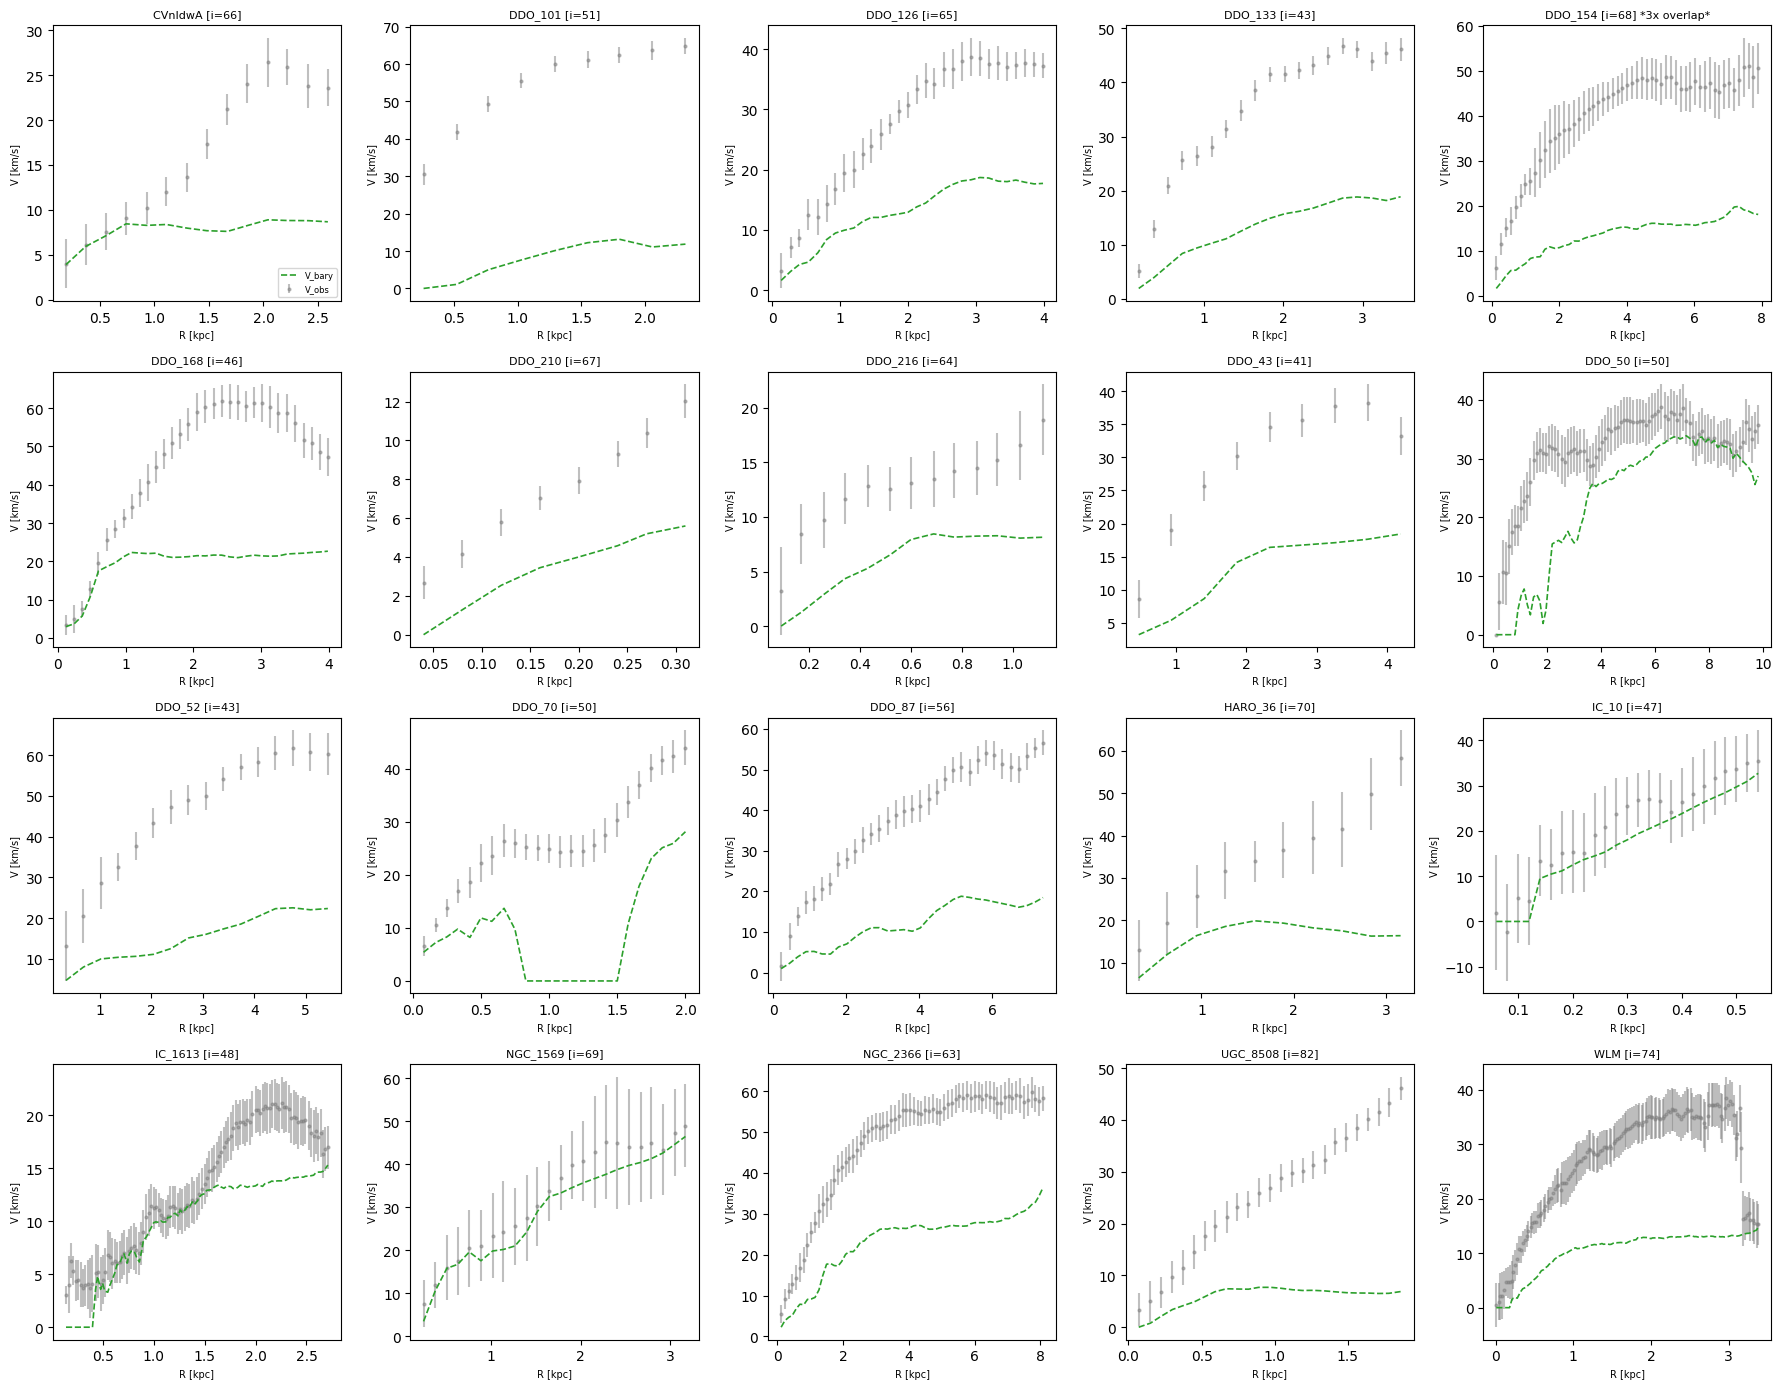

In [6]:
names = sorted(profiles.keys())
ncols = 5
nrows = (len(names) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows), squeeze=False)

for idx, name in enumerate(names):
    ax = axes[idx // ncols][idx % ncols]
    prof = profiles[name]
    r = prof["radius_kpc"].values
    v_obs = prof["v_obs"].values
    v_err = prof["v_err"].values
    v_bary = prof["v_baryon_total"].values

    ax.errorbar(r, v_obs, yerr=v_err, fmt="o", ms=2, color="grey",
                alpha=0.5, label="V_obs", zorder=1)
    ax.plot(r, v_bary, "--", color="C2", linewidth=1.2, label="V_bary", zorder=2)

    incl = gal_df.loc[gal_df["Name"] == name, "i"].values[0]
    title = f"{name} [i={incl:.0f}]"
    if name == "DDO_154":
        title += " *3x overlap*"
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("R [kpc]", fontsize=7)
    ax.set_ylabel("V [km/s]", fontsize=7)
    if idx == 0:
        ax.legend(fontsize=6, loc="lower right")

for j in range(len(names), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.tight_layout()
plt.savefig(results_dir / "NB11_lt_rotation_curves.png", dpi=150)
plt.show()

## 6. DDO 154 Triple-Overlap Comparison

DDO 154 appears in SPARC, THINGS, and LITTLE THINGS. Compare V_obs and V_bary
across all three pipelines.

Note: SPARC distance = 4.04 Mpc, THINGS distance = 4.04 Mpc,
LITTLE THINGS distance = 3.7 Mpc. The distance difference is baked into
the LITTLE THINGS normalized curves and is not corrected here.

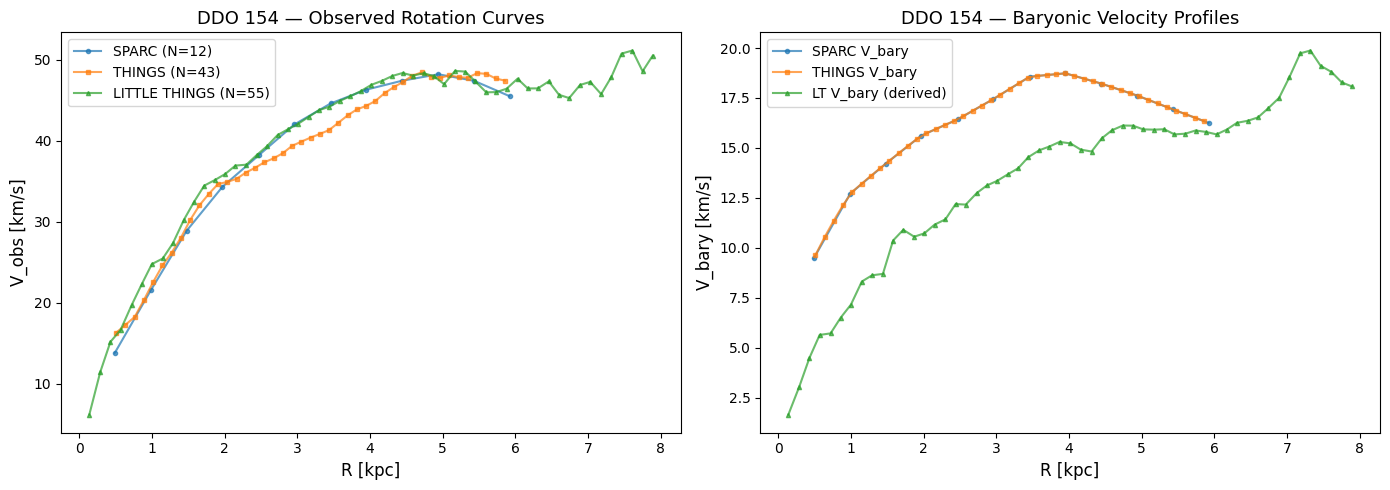

DDO 154 Pipeline Comparison
  SPARC          : N= 12, R_max=5.92 kpc, V_max=48.2 km/s
  THINGS         : N= 43, R_max=5.86 kpc, V_max=48.4 km/s
  LITTLE THINGS  : N= 55, R_max=7.89 kpc, V_max=51.1 km/s


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Load SPARC and THINGS profiles from DB
sparc_prof = query_profiles_as_dataframe(session, "DDO154")
things_prof = query_profiles_as_dataframe(session, "DDO154_THINGS")
lt_prof = profiles.get("DDO_154")

# Left panel: V_obs comparison
ax = axes[0]
if not sparc_prof.empty:
    ax.plot(sparc_prof["radius_kpc"], sparc_prof["v_obs"], "o-", ms=3,
            label=f"SPARC (N={len(sparc_prof)})", alpha=0.7)
if not things_prof.empty:
    ax.plot(things_prof["radius_kpc"], things_prof["v_obs"], "s-", ms=3,
            label=f"THINGS (N={len(things_prof)})", alpha=0.7)
if lt_prof is not None:
    ax.plot(lt_prof["radius_kpc"], lt_prof["v_obs"], "^-", ms=3,
            label=f"LITTLE THINGS (N={len(lt_prof)})", alpha=0.7)
ax.set_xlabel("R [kpc]", fontsize=12)
ax.set_ylabel("V_obs [km/s]", fontsize=12)
ax.set_title("DDO 154 — Observed Rotation Curves", fontsize=13)
ax.legend(fontsize=10)

# Right panel: V_bary comparison
ax = axes[1]
if not sparc_prof.empty:
    ax.plot(sparc_prof["radius_kpc"], sparc_prof["v_baryon_total"], "o-", ms=3,
            label="SPARC V_bary", alpha=0.7)
if not things_prof.empty:
    ax.plot(things_prof["radius_kpc"], things_prof["v_baryon_total"], "s-", ms=3,
            label="THINGS V_bary", alpha=0.7)
if lt_prof is not None:
    ax.plot(lt_prof["radius_kpc"], lt_prof["v_baryon_total"], "^-", ms=3,
            label="LT V_bary (derived)", alpha=0.7)
ax.set_xlabel("R [kpc]", fontsize=12)
ax.set_ylabel("V_bary [km/s]", fontsize=12)
ax.set_title("DDO 154 — Baryonic Velocity Profiles", fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / "NB11_ddo154_comparison.png", dpi=150)
plt.show()

# Print summary
print("DDO 154 Pipeline Comparison")
print("=" * 50)
for label, df in [("SPARC", sparc_prof), ("THINGS", things_prof)]:
    if not df.empty:
        print(f"  {label:15s}: N={len(df):3d}, "
              f"R_max={df['radius_kpc'].max():.2f} kpc, "
              f"V_max={df['v_obs'].max():.1f} km/s")
if lt_prof is not None:
    print(f"  {'LITTLE THINGS':15s}: N={len(lt_prof):3d}, "
          f"R_max={lt_prof['radius_kpc'].max():.2f} kpc, "
          f"V_max={lt_prof['v_obs'].max():.1f} km/s")

## 7. Insert into Database

Galaxy ID format: `{Name}_LITTLE_THINGS` (e.g., `DDO_154_LITTLE_THINGS`).

For radial profiles, `v_gas`, `v_disk`, `v_bulge` are set to 0.0 since LITTLE THINGS
does not provide component separation. Only `v_baryon_total` is populated from the
derived V_bary profiles.

In [8]:
inserted_count = 0
skipped_count = 0

for name, prof in sorted(profiles.items()):
    gid = f"{name}_LITTLE_THINGS"

    # Skip if already exists (idempotent)
    existing = session.query(Galaxy).filter(Galaxy.galaxy_id == gid).first()
    if existing is not None:
        # Delete existing profiles and galaxy for clean re-insert
        session.query(RadialProfile).filter(RadialProfile.galaxy_id == gid).delete()
        session.query(Galaxy).filter(Galaxy.galaxy_id == gid).delete()
        session.commit()

    # Get metadata
    meta = gal_df[gal_df["Name"] == name].iloc[0]

    # Insert galaxy
    galaxy = Galaxy(
        galaxy_id=gid,
        distance_mpc=float(meta["Dist"]),
        inclination=float(meta["i"]),
        data_source="LITTLE_THINGS",
    )
    session.add(galaxy)

    # Insert radial profiles
    for _, row in prof.iterrows():
        rp = RadialProfile(
            galaxy_id=gid,
            radius_kpc=float(row["radius_kpc"]),
            v_obs=float(row["v_obs"]),
            v_err=float(row["v_err"]),
            v_gas=0.0,
            v_disk=0.0,
            v_bulge=0.0,
            v_baryon_total=float(row["v_baryon_total"]),
        )
        session.add(rp)

    session.commit()
    inserted_count += 1

print(f"Inserted {inserted_count} galaxies into database with data_source='LITTLE_THINGS'")

# Verify
lt_in_db = session.query(Galaxy).filter(Galaxy.data_source == "LITTLE_THINGS").count()
lt_profiles = session.query(RadialProfile).filter(
    RadialProfile.galaxy_id.like("%_LITTLE_THINGS")
).count()
print(f"Verification: {lt_in_db} galaxies, {lt_profiles} profile rows in DB")

Inserted 20 galaxies into database with data_source='LITTLE_THINGS'
Verification: 20 galaxies, 751 profile rows in DB


## 8. QC Summary Table

In [9]:
qc_rows = []
for _, r in gal_df.iterrows():
    name = r["Name"]
    status = "PASS"
    reason = ""
    if not r["qc_pass"]:
        status = "FAIL_INCL"
        reason = f"i={r['i']:.1f} < 30 deg"
    elif name not in dm_data:
        status = "FAIL_NO_DM"
        reason = "No DM rotation curve"
    n_pts = len(profiles.get(name, []))
    r_max = profiles[name]["radius_kpc"].max() if name in profiles else np.nan
    qc_rows.append({
        "Name": name,
        "Distance_Mpc": r["Dist"],
        "Inclination": r["i"],
        "N_points": n_pts,
        "R_max_kpc": r_max,
        "Mgas_1e7": r["Mgas"],
        "MstarSED_1e7": r["MstarSED"],
        "QC_status": status,
        "QC_reason": reason,
    })

qc_df = pd.DataFrame(qc_rows)
qc_df.to_csv(results_dir / "NB11_little_things_qc.csv", index=False)

print(f"{'Name':12s} {'Dist':>5s} {'i':>5s} {'N':>4s} {'Rmax':>6s} {'Status':>10s} {'Reason'}")
print("-" * 65)
for _, r in qc_df.iterrows():
    print(f"{r['Name']:12s} {r['Distance_Mpc']:5.1f} {r['Inclination']:5.1f} "
          f"{r['N_points']:4.0f} {r['R_max_kpc']:6.2f} {r['QC_status']:>10s} {r['QC_reason']}")

print(f"\nSummary: {(qc_df['QC_status'] == 'PASS').sum()} PASS, "
      f"{(qc_df['QC_status'] == 'FAIL_INCL').sum()} FAIL_INCL, "
      f"{(qc_df['QC_status'] == 'FAIL_NO_DM').sum()} FAIL_NO_DM")
print(f"Saved to results/NB11_little_things_qc.csv")

Name          Dist     i    N   Rmax     Status Reason
-----------------------------------------------------------------
CVnIdwA        3.6  66.5   14   2.59       PASS 
DDO_43         7.8  40.6    9   4.19       PASS 
DDO_46         6.1  27.9    0    nan  FAIL_INCL i=27.9 < 30 deg
DDO_47         5.2  45.5    0    nan FAIL_NO_DM No DM rotation curve
DDO_50         3.4  49.7   85   9.81       PASS 
DDO_52        10.3  43.0   16   5.43       PASS 
DDO_53         3.6  27.0    0    nan  FAIL_INCL i=27.0 < 30 deg
DDO_70         1.3  50.0   24   2.00       PASS 
DDO_87         7.7  55.5   33   7.39       PASS 
DDO_101        6.4  51.0    9   2.32       PASS 
DDO_126        4.9  65.0   30   3.99       PASS 
DDO_133        3.5  43.4   19   3.48       PASS 
DDO_154        3.7  68.2   55   7.89       PASS 
DDO_168        4.3  46.5   33   3.99       PASS 
DDO_210        0.9  66.7    8   0.31       PASS 
DDO_216        1.1  63.7   13   1.12       PASS 
F564-V3        8.7  56.5    0    nan FAIL_NO_

## 9. Gate Check

In [10]:
checks = {
    "26 galaxies assessed": len(gal_df) == 26,
    "Inclination QC applied (i >= 30 deg)": n_fail >= 1,
    "DDO 154 flagged as triple-overlap": "DDO_154" in profiles,
    "All inserted galaxies have profiles": lt_profiles > 0,
    "No NaN in v_baryon_total": all(
        not prof["v_baryon_total"].isna().any() for prof in profiles.values()
    ),
    "V_bary derivation documented": True,
    "Beam-smearing status documented": True,
}

print("GATE CHECK: NB11 -- LITTLE THINGS Ingestion")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB11 COMPLETE -- proceed to NB12 <<<")
else:
    print("  >>> NB11 has failures -- diagnose before proceeding <<<")

session.close()

GATE CHECK: NB11 -- LITTLE THINGS Ingestion
  [PASS] 26 galaxies assessed
  [PASS] Inclination QC applied (i >= 30 deg)
  [PASS] DDO 154 flagged as triple-overlap
  [PASS] All inserted galaxies have profiles
  [PASS] No NaN in v_baryon_total
  [PASS] V_bary derivation documented
  [PASS] Beam-smearing status documented

  >>> NB11 COMPLETE -- proceed to NB12 <<<
